# 人机交互

要在代理或工作流中审查、编辑和批准工具调用，请使用 LangGraph 的人机交互功能，在工作流的任何环节启用人工干预。这在大型语言模型 (LLM) 驱动的应用程序中尤其有用，因为这些应用程序中的模型输出可能需要验证、更正或补充上下文。

<img src="https://langchain-ai.github.io/langgraph/concepts/img/human_in_the_loop/tool-call-review.png">

有关如何使用人机交互的更多信息，请参阅启用人工干预和使用服务器 API 实现人机交互。

## 关键功能¶
持久执行状态：中断使用 LangGraph 的持久层（该层会保存图形状态）无限期暂停图形执行，直到您恢复执行。这是因为 LangGraph 在每个步骤后都会对图形状态进行检查点设置，这使得系统能够持久保存执行上下文，并在之后恢复工作流，从中断处继续执行。这支持不受时间限制的异步人工审核或输入。

暂停图表有两种方法：

- 动态中断：根据图形的当前状态，使用`interrupt`从特定节点内部暂停图形。
- 静态中断：使用 `interrupt_before` 和 `interrupt_after` 在节点执行之前或之后的预定义点暂停图形。


<img src="https://langchain-ai.github.io/langgraph/concepts/img/breakpoints.png">

- 灵活的集成点：人机交互逻辑可在工作流程的任何环节引入。这允许有针对性的人工参与，例如批准 API 调用、修正输出或引导对话。


## 模式¶


您可以使用`interrupt`和`Command`来实现四种典型的设计模式：
- 批准或拒绝：在关键步骤（例如 API 调用）之前暂停图表，以审核并批准操作。如果操作被拒绝，您可以阻止图表执行该步骤，并可能采取其他操作。此模式通常涉及根据人工输入对图表进行路由。
- 编辑图表状态：暂停图表以查看和编辑图表状态。这对于纠正错误或使用附加信息更新状态非常有用。此模式通常涉及使用人工输入来更新状态。
- 审查工具调用：暂停图表以在工具执行之前审查和编辑 LLM 请求的工具调用。
- 验证人工输入：在继续下一步之前，暂停图表以验证人工输入。


# 启用人工干预

要在代理或工作流中审核、编辑和批准工具调用，请使用中断来暂停图表并等待人工输入。中断使用 LangGraph 的持久层（该层会保存图表状态）无限期暂停图表执行，直到您恢复为止。

> 有关人机循环工作流程的更多信息，请参阅人机循环概念指南。

## 暂停使用interrupt

动态中断（也称为动态断点）根据图表的当前状态触发。您可以通过在适当的位置调用interrupt函数来设置动态中断。图表将暂停，以便人工干预，然后根据人工输入恢复图表。这对于审批、编辑或收集其他上下文等任务非常有用。

要在图表中使用`interrupt`，您需要：

- 指定一个检查点来保存每个步骤之后的图形状态。
- 在适当的地方调用`interrupt()`。有关示例，请参阅常见模式部分。
- 使用线程 ID运行图表，直到`interrupt`命中。
- 使用`invoke/stream`恢复执行（参见原Command语）。



In [ ]:
from langgraph.types import interrupt, Command

def human_node(state: State):
    value = interrupt( 
        {
            "text_to_revise": state["some_text"] 
        }
    )
    return {
        "some_text": value 
    }


graph = graph_builder.compile(checkpointer=checkpointer) 

# Run the graph until the interrupt is hit.
config = {"configurable": {"thread_id": "some_id"}}
result = graph.invoke({"some_text": "original text"}, config=config) 
print(result['__interrupt__']) 
# > [
# >    Interrupt(
# >       value={'text_to_revise': 'original text'},
# >       resumable=True,
# >       ns=['human_node:6ce9e64f-edef-fe5d-f7dc-511fa9526960']
# >    )
# > ]

print(graph.invoke(Command(resume="Edited text"), config=config)) 
# > {'some_text': 'Edited text'}

### 扩展示例：使用interrupt

In [ ]:
from typing import TypedDict
import uuid
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.constants import START
from langgraph.graph import StateGraph

from langgraph.types import interrupt, Command


class State(TypedDict):
    some_text: str


def human_node(state: State):
    value = interrupt(  
        {
            "text_to_revise": state["some_text"]  
        }
    )
    return {
        "some_text": value  
    }


# Build the graph
graph_builder = StateGraph(State)
graph_builder.add_node("human_node", human_node)
graph_builder.add_edge(START, "human_node")
checkpointer = InMemorySaver()  
graph = graph_builder.compile(checkpointer=checkpointer)
# Pass a thread ID to the graph to run it.
config = {"configurable": {"thread_id": uuid.uuid4()}}
# Run the graph until the interrupt is hit.
result = graph.invoke({"some_text": "original text"}, config=config)  

print(result['__interrupt__']) 
# > [
# >    Interrupt(
# >       value={'text_to_revise': 'original text'},
# >       resumable=True,
# >       ns=['human_node:6ce9e64f-edef-fe5d-f7dc-511fa9526960']
# >    )
# > ]
print(result["__interrupt__"])  
# > [Interrupt(value={'text_to_revise': 'original text'}, id='6d7c4048049254c83195429a3659661d')]

print(graph.invoke(Command(resume="Edited text"), config=config)) 
# > {'some_text': 'Edited text'}

## 使用Command原始恢复

> 从一个位置恢复interrupt与 Python 的函数不同，Python 的函数执行从调用函数的input()确切位置恢复。input()

在图形中使用中断函数时，执行会在该点暂停，等待用户输入。

要恢复执行，可使用命令基元，该基元可通过 invoke 或 stream 方法提供。图形会从最初调用 interrupt(...) 的节点开始恢复执行。这一次，中断函数将返回 `Command(resume=value) `中提供的值，而不是再次暂停。从节点开始到中断的所有代码都将重新执行。

In [ ]:
# Resume graph execution by providing the user's input.
graph.invoke(Command(resume={"age": "25"}), thread_config)

## 一次调用即可恢复多个中断¶
当具有中断条件的节点并行运行时，任务队列中可能会有多个中断。例如，下图有两个并行运行的节点需要人工输入：

<img src="https://langchain-ai.github.io/langgraph/how-tos/assets/human_in_loop_parallel.png">

一旦你的图表被中断并停滞，你可以使用`Command.resume`一次性恢复所有中断，传递中断 ID 到恢复值的字典映射。

API 参考：RunnableConfig | InMemorySaver | START | StateGraph | interrupt | Command

In [ ]:
from typing import TypedDict
import uuid
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.constants import START
from langgraph.graph import StateGraph
from langgraph.types import interrupt, Command


class State(TypedDict):
    text_1: str
    text_2: str


def human_node_1(state: State):
    value = interrupt({"text_to_revise": state["text_1"]})
    return {"text_1": value}


def human_node_2(state: State):
    value = interrupt({"text_to_revise": state["text_2"]})
    return {"text_2": value}


graph_builder = StateGraph(State)
graph_builder.add_node("human_node_1", human_node_1)
graph_builder.add_node("human_node_2", human_node_2)

# Add both nodes in parallel from START
graph_builder.add_edge(START, "human_node_1")
graph_builder.add_edge(START, "human_node_2")

checkpointer = InMemorySaver()
graph = graph_builder.compile(checkpointer=checkpointer)

thread_id = str(uuid.uuid4())
config: RunnableConfig = {"configurable": {"thread_id": thread_id}}
result = graph.invoke(
    {"text_1": "original text 1", "text_2": "original text 2"}, config=config
)

# Resume with mapping of interrupt IDs to values
resume_map = {
    i.interrupt_id: f"human input for prompt {i.value}"
    for i in parent.get_state(thread_config).interrupts
}
print(graph.invoke(Command(resume=resume_map), config=config))
# > {'text_1': 'edited text for original text 1', 'text_2': 'edited text for original text 2'}

## 常见模式¶
下面我们展示可以使用interrupt和Command实现的不同设计模式。


### 批准或拒绝¶

<img src="https://langchain-ai.github.io/langgraph/concepts/img/human_in_the_loop/approve-or-reject.png">

根据人类的批准或拒绝，图表可以继续执行操作或采取其他路径。

在关键步骤（例如 API 调用）之前暂停图表，以审核并批准操作。如果操作被拒绝，您可以阻止图表执行该步骤，并可能采取其他操作。

In [ ]:
from typing import Literal
from langgraph.types import interrupt, Command

def human_approval(state: State) -> Command[Literal["some_node", "another_node"]]:
    is_approved = interrupt(
        {
            "question": "Is this correct?",
            # Surface the output that should be
            # reviewed and approved by the human.
            "llm_output": state["llm_output"]
        }
    )

    if is_approved:
        return Command(goto="some_node")
    else:
        return Command(goto="another_node")

# Add the node to the graph in an appropriate location
# and connect it to the relevant nodes.
graph_builder.add_node("human_approval", human_approval)
graph = graph_builder.compile(checkpointer=checkpointer)

# After running the graph and hitting the interrupt, the graph will pause.
# Resume it with either an approval or rejection.
thread_config = {"configurable": {"thread_id": "some_id"}}
graph.invoke(Command(resume=True), config=thread_config)

### 扩展示例：通过中断批准或拒绝



In [ ]:
from typing import Literal, TypedDict
import uuid

from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver

# Define the shared graph state
class State(TypedDict):
    llm_output: str
    decision: str

# Simulate an LLM output node
def generate_llm_output(state: State) -> State:
    return {"llm_output": "This is the generated output."}

# Human approval node
def human_approval(state: State) -> Command[Literal["approved_path", "rejected_path"]]:
    decision = interrupt({
        "question": "Do you approve the following output?",
        "llm_output": state["llm_output"]
    })

    if decision == "approve":
        return Command(goto="approved_path", update={"decision": "approved"})
    else:
        return Command(goto="rejected_path", update={"decision": "rejected"})

# Next steps after approval
def approved_node(state: State) -> State:
    print("✅ Approved path taken.")
    return state

# Alternative path after rejection
def rejected_node(state: State) -> State:
    print("❌ Rejected path taken.")
    return state

# Build the graph
builder = StateGraph(State)
builder.add_node("generate_llm_output", generate_llm_output)
builder.add_node("human_approval", human_approval)
builder.add_node("approved_path", approved_node)
builder.add_node("rejected_path", rejected_node)

builder.set_entry_point("generate_llm_output")
builder.add_edge("generate_llm_output", "human_approval")
builder.add_edge("approved_path", END)
builder.add_edge("rejected_path", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

# Run until interrupt
config = {"configurable": {"thread_id": uuid.uuid4()}}
result = graph.invoke({}, config=config)
print(result["__interrupt__"])
# Output:
# Interrupt(value={'question': 'Do you approve the following output?', 'llm_output': 'This is the generated output.'}, ...)

# Simulate resuming with human input
# To test rejection, replace resume="approve" with resume="reject"
final_result = graph.invoke(Command(resume="approve"), config=config)
print(final_result)

## 审阅和编辑状态

<img src="https://langchain-ai.github.io/langgraph/concepts/img/human_in_the_loop/edit-graph-state-simple.png">

API 参考：中断

In [ ]:
from langgraph.types import interrupt

def human_editing(state: State):
    ...
    result = interrupt(
        # Interrupt information to surface to the client.
        # Can be any JSON serializable value.
        {
            "task": "Review the output from the LLM and make any necessary edits.",
            "llm_generated_summary": state["llm_generated_summary"]
        }
    )

    # Update the state with the edited text
    return {
        "llm_generated_summary": result["edited_text"]
    }

# Add the node to the graph in an appropriate location
# and connect it to the relevant nodes.
graph_builder.add_node("human_editing", human_editing)
graph = graph_builder.compile(checkpointer=checkpointer)

...

# After running the graph and hitting the interrupt, the graph will pause.
# Resume it with the edited text.
thread_config = {"configurable": {"thread_id": "some_id"}}
graph.invoke(
    Command(resume={"edited_text": "The edited text"}),
    config=thread_config
)

### 扩展示例：带中断的编辑状态



In [ ]:
from typing import TypedDict
import uuid

from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver

# Define the graph state
class State(TypedDict):
    summary: str

# Simulate an LLM summary generation
def generate_summary(state: State) -> State:
    return {
        "summary": "The cat sat on the mat and looked at the stars."
    }

# Human editing node
def human_review_edit(state: State) -> State:
    result = interrupt({
        "task": "Please review and edit the generated summary if necessary.",
        "generated_summary": state["summary"]
    })
    return {
        "summary": result["edited_summary"]
    }

# Simulate downstream use of the edited summary
def downstream_use(state: State) -> State:
    print(f"✅ Using edited summary: {state['summary']}")
    return state

# Build the graph
builder = StateGraph(State)
builder.add_node("generate_summary", generate_summary)
builder.add_node("human_review_edit", human_review_edit)
builder.add_node("downstream_use", downstream_use)

builder.set_entry_point("generate_summary")
builder.add_edge("generate_summary", "human_review_edit")
builder.add_edge("human_review_edit", "downstream_use")
builder.add_edge("downstream_use", END)

# Set up in-memory checkpointing for interrupt support
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

# Invoke the graph until it hits the interrupt
config = {"configurable": {"thread_id": uuid.uuid4()}}
result = graph.invoke({}, config=config)

# Output interrupt payload
print(result["__interrupt__"])
# Example output:
# > [
# >     Interrupt(
# >         value={
# >             'task': 'Please review and edit the generated summary if necessary.',
# >             'generated_summary': 'The cat sat on the mat and looked at the stars.'
# >         },
# >         id='...'
# >     )
# > ]

# Resume the graph with human-edited input
edited_summary = "The cat lay on the rug, gazing peacefully at the night sky."
resumed_result = graph.invoke(
    Command(resume={"edited_summary": edited_summary}),
    config=config
)
print(resumed_result)

### 审查工具调用

<img src="https://langchain-ai.github.io/langgraph/concepts/img/human_in_the_loop/tool-call-review.png">
在继续操作之前，人工可以检查并编辑 LLM 的输出。这在 LLM 请求的工具调用可能比较敏感或需要人工监督的应用中尤为重要。

要向工具添加人工批准步骤：

- 在工具中使用interrupt()来暂停执行。
- 根据人工输入继续执行Command。


In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt
from langgraph.prebuilt import create_react_agent

# An example of a sensitive tool that requires human review / approval
def book_hotel(hotel_name: str):
    """Book a hotel"""
    response = interrupt(  
        f"Trying to call `book_hotel` with args {{'hotel_name': {hotel_name}}}. "
        "Please approve or suggest edits."
    )
    if response["type"] == "accept":
        pass
    elif response["type"] == "edit":
        hotel_name = response["args"]["hotel_name"]
    else:
        raise ValueError(f"Unknown response type: {response['type']}")
    return f"Successfully booked a stay at {hotel_name}."

checkpointer = InMemorySaver() 

agent = create_react_agent(
    model="anthropic:claude-3-5-sonnet-latest",
    tools=[book_hotel],
    checkpointer=checkpointer, 
)

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt
from langgraph.prebuilt import create_react_agent

# An example of a sensitive tool that requires human review / approval
def book_hotel(hotel_name: str):
    """Book a hotel"""
    response = interrupt(  
        f"Trying to call `book_hotel` with args {{'hotel_name': {hotel_name}}}. "
        "Please approve or suggest edits."
    )
    if response["type"] == "accept":
        pass
    elif response["type"] == "edit":
        hotel_name = response["args"]["hotel_name"]
    else:
        raise ValueError(f"Unknown response type: {response['type']}")
    return f"Successfully booked a stay at {hotel_name}."

checkpointer = InMemorySaver() 

agent = create_react_agent(
    model="anthropic:claude-3-5-sonnet-latest",
    tools=[book_hotel],
    checkpointer=checkpointer, 
)

使用 `stream() `方法运行代理，通过config对象指定线程 ID。这样，代理就能在以后的调用中继续进行相同的对话。

In [ ]:
config = {
   "configurable": {
      "thread_id": "1"
   }
}

for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "book a stay at McKittrick hotel"}]},
    config
):
    print(chunk)
    print("\n")

你应该看到，代理程序运行到 `interrupt()` 调用之前，会暂停并等待人类输入。

根据人工输入的Command，让代理继续运行

In [ ]:
from langgraph.types import Command

for chunk in agent.stream(
    Command(resume={"type": "accept"}),  
    # Command(resume={"type": "edit", "args": {"hotel_name": "McKittrick Hotel"}}),
    config
):
    print(chunk)
    print("\n")

### 为任何工具添加中断¶
您可以创建一个包装器，将中断添加到任何工具中。以下示例提供了与`Agent Inbox UI`和`Agent Chat UI`兼容的参考实现。



In [ ]:
from typing import Callable
from langchain_core.tools import BaseTool, tool as create_tool
from langchain_core.runnables import RunnableConfig
from langgraph.types import interrupt
from langgraph.prebuilt.interrupt import HumanInterruptConfig, HumanInterrupt

def add_human_in_the_loop(
    tool: Callable | BaseTool,
    *,
    interrupt_config: HumanInterruptConfig = None,
) -> BaseTool:
    """Wrap a tool to support human-in-the-loop review."""
    if not isinstance(tool, BaseTool):
        tool = create_tool(tool)

    if interrupt_config is None:
        interrupt_config = {
            "allow_accept": True,
            "allow_edit": True,
            "allow_respond": True,
        }

    @create_tool(  
        tool.name,
        description=tool.description,
        args_schema=tool.args_schema
    )
    def call_tool_with_interrupt(config: RunnableConfig, **tool_input):
        request: HumanInterrupt = {
            "action_request": {
                "action": tool.name,
                "args": tool_input
            },
            "config": interrupt_config,
            "description": "Please review the tool call"
        }
        response = interrupt([request])[0]  
        # approve the tool call
        if response["type"] == "accept":
            tool_response = tool.invoke(tool_input, config)
        # update tool call args
        elif response["type"] == "edit":
            tool_input = response["args"]["args"]
            tool_response = tool.invoke(tool_input, config)
        # respond to the LLM with user feedback
        elif response["type"] == "response":
            user_feedback = response["args"]
            tool_response = user_feedback
        else:
            raise ValueError(f"Unsupported interrupt response type: {response['type']}")

        return tool_response

    return call_tool_with_interrupt

您可以使用包装器添加interrupt()到任何工具中，而不必将其添加到工具内部：

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import create_react_agent

checkpointer = InMemorySaver()

def book_hotel(hotel_name: str):
   """Book a hotel"""
   return f"Successfully booked a stay at {hotel_name}."


agent = create_react_agent(
    model="anthropic:claude-3-5-sonnet-latest",
    tools=[
        add_human_in_the_loop(book_hotel), 
    ],
    checkpointer=checkpointer,
)

config = {"configurable": {"thread_id": "1"}}

# Run the agent
for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "book a stay at McKittrick hotel"}]},
    config
):
    print(chunk)
    print("\n")

根据人工输入Command恢复代理以继续。

In [ ]:
from langgraph.types import Command

for chunk in agent.stream(
    Command(resume=[{"type": "accept"}]),
    # Command(resume=[{"type": "edit", "args": {"args": {"hotel_name": "McKittrick Hotel"}}}]),
    config
):
    print(chunk)
    print("\n")

### 验证人工输入
如果您需要在图表本身内（而不是在客户端）验证人类提供的输入，则可以通过在单个节点内使用多个中断调用来实现这一点。

In [ ]:
from langgraph.types import interrupt

def human_node(state: State):
    """Human node with validation."""
    question = "What is your age?"

    while True:
        answer = interrupt(question)

        # Validate answer, if the answer isn't valid ask for input again.
        if not isinstance(answer, int) or answer < 0:
            question = f"'{answer} is not a valid age. What is your age?"
            answer = None
            continue
        else:
            # If the answer is valid, we can proceed.
            break

    print(f"The human in the loop is {answer} years old.")
    return {
        "age": answer
    }

### 扩展示例：验证用户输入

In [ ]:
from typing import TypedDict
import uuid

from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver

# Define graph state
class State(TypedDict):
    age: int

# Node that asks for human input and validates it
def get_valid_age(state: State) -> State:
    prompt = "Please enter your age (must be a non-negative integer)."

    while True:
        user_input = interrupt(prompt)

        # Validate the input
        try:
            age = int(user_input)
            if age < 0:
                raise ValueError("Age must be non-negative.")
            break  # Valid input received
        except (ValueError, TypeError):
            prompt = f"'{user_input}' is not valid. Please enter a non-negative integer for age."

    return {"age": age}

# Node that uses the valid input
def report_age(state: State) -> State:
    print(f"✅ Human is {state['age']} years old.")
    return state

# Build the graph
builder = StateGraph(State)
builder.add_node("get_valid_age", get_valid_age)
builder.add_node("report_age", report_age)

builder.set_entry_point("get_valid_age")
builder.add_edge("get_valid_age", "report_age")
builder.add_edge("report_age", END)

# Create the graph with a memory checkpointer
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

# Run the graph until the first interrupt
config = {"configurable": {"thread_id": uuid.uuid4()}}
result = graph.invoke({}, config=config)
print(result["__interrupt__"])  # First prompt: "Please enter your age..."

# Simulate an invalid input (e.g., string instead of integer)
result = graph.invoke(Command(resume="not a number"), config=config)
print(result["__interrupt__"])  # Follow-up prompt with validation message

# Simulate a second invalid input (e.g., negative number)
result = graph.invoke(Command(resume="-10"), config=config)
print(result["__interrupt__"])  # Another retry

# Provide valid input
final_result = graph.invoke(Command(resume="25"), config=config)
print(final_result)  # Should include the valid age

## 使用中断进行调试
要调试和测试图形，可使用静态中断（也称为静态断点），一次一个节点地逐步执行图形，或在特定节点暂停图形的执行。静态中断在节点执行之前或之后的指定点触发。您可以在编译时或运行时指定 `interrupt_before` 和 `interrupt_after`，从而设置静态中断。

In [ ]:

## 编译
graph = graph_builder.compile( 
    interrupt_before=["node_a"], 
    interrupt_after=["node_b", "node_c"], 
    checkpointer=checkpointer, 
)

config = {
    "configurable": {
        "thread_id": "some_thread"
    }
}

# Run the graph until the breakpoint
graph.invoke(inputs, config=thread_config) 

# Resume the graph
graph.invoke(None, config=thread_config)


### 运行时
graph.invoke( 
    inputs,
    interrupt_before=["node_a"], 
    interrupt_after=["node_b", "node_c"] 
    config={
        "configurable": {"thread_id": "some_thread"}
    },
)

config = {
    "configurable": {
        "thread_id": "some_thread"
    }
}

# Run the graph until the breakpoint
graph.invoke(inputs, config=config) 

# Resume the graph
graph.invoke(None, config=config)


您无法在运行时为子图设置静态断点。如果您有子图，则必须在编译时设置断点。

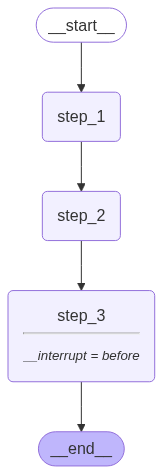

{'input': 'hello world'}
---Step 1---
---Step 2---
StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': 'some_thread'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())
{'input': 'hello world'}
---Step 3---


In [2]:
from IPython.display import Image, display
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
    input: str


def step_1(state):
    print("---Step 1---")
    pass


def step_2(state):
    print("---Step 2---")
    pass


def step_3(state):
    print("---Step 3---")
    pass


builder = StateGraph(State)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

# Set up a checkpointer
checkpointer = InMemorySaver() # (1)!

graph = builder.compile(
    checkpointer=checkpointer, # (2)!
    interrupt_before=["step_3"] # (3)!
)

# View
display(Image(graph.get_graph().draw_mermaid_png()))


# Input
initial_input = {"input": "hello world"}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    print(event)

config = {
    "configurable": {
        "thread_id": "some_thread"
    }
}

# This will run until the breakpoint
# You can get the state of the graph at this point
print(graph.get_state(config))

# You can continue the graph execution by passing in `None` for the input
for event in graph.stream(None, thread, stream_mode="values"):
    print(event)

## 在 LangGraph Studio 中使用静态中断¶
您可以使用LangGraph Studio调试图表。您可以在 UI 中设置静态断点，然后运行图表。您还可以使用 UI 在执行过程中的任何时间点检查图表状态。

<img src="https://langchain-ai.github.io/langgraph/concepts/img/human_in_the_loop/static-interrupt.png">

LangGraph Studio 是免费的，可以使用`langgraph dev`进行本地部署的应用程序。

## 注意事项¶
当使用人机交互时，需要牢记一些注意事项。

### 使用有副作用的代码¶
将具有副作用的代码（例如 API 调用）放置在interrupt或单独的节点之后以避免重复，因为每次恢复节点时都会重新触发这些代码。

In [ ]:



### 中断后的副作用


from langgraph.types import interrupt

def human_node(state: State):
    """Human node with validation."""

    answer = interrupt(question)

    api_call(answer) # OK as it's after the interrupt



In [ ]:
#### 单独节点的副作用
from langgraph.types import interrupt

def human_node(state: State):
    """Human node with validation."""

    answer = interrupt(question)

    return {
        "answer": answer
    }

def api_call_node(state: State):
    api_call(...) # OK as it's in a separate node

### 使用称为函数的子图¶

当将子图作为函数调用时，父图将从调用子图的节点的开头恢复执行，该节点的开头触发了中断。同样，子图将从调用 interrupt（） 函数的节点的开头恢复。

### 在单个节点中使用多个中断¶
在单个节点中使用多个中断对于验证人工输入等模式很有帮助。但是，如果处理不当，在同一个节点中使用多个中断可能会导致意外行为。

当一个节点包含多个中断调用时，LangGraph 会保存一个特定于执行该节点的任务的恢复值列表。每当执行恢复时，它都会从节点的开头开始。对于遇到的每个中断，LangGraph 都会检查任务的恢复列表中是否存在匹配的值。匹配严格基于索引，因此节点内中断调用的顺序至关重要。

为避免问题，请避免在执行之间动态更改节点的结构。这包括添加、移除或重新排序中断调用，因为此类更改可能会导致索引不匹配。这些问题通常源于非常规模式，例如通过全局变量改变状态Command(resume=..., update=SOME_STATE_MUTATION)或依赖全局变量来动态修改节点的结构。

# 使用服务器 API 的人机交互
要审查、编辑和批准代理或工作流中的工具调用，请使用 LangGraph 的人机交互功能。

## 动态中断¶


In [ ]:
from langgraph_sdk import get_client
from langgraph_sdk.schema import Command
client = get_client(url=<DEPLOYMENT_URL>)

# Using the graph deployed with the name "agent"
assistant_id = "agent"

# create a thread
thread = await client.threads.create()
thread_id = thread["thread_id"]

# Run the graph until the interrupt is hit.
result = await client.runs.wait(
    thread_id,
    assistant_id,
    input={"some_text": "original text"}   
)

print(result['__interrupt__']) 
# > [
# >     {
# >         'value': {'text_to_revise': 'original text'},
# >         'id': '...',
# >     }
# > ]


# Resume the graph
print(await client.runs.wait(
    thread_id,
    assistant_id,
    command=Command(resume="Edited text")   
))
# > {'some_text': 'Edited text'}

### 静态中断
静态中断（也称为静态断点）在节点执行之前或之后触发。

您可以通过在编译时指定interrupt_before\interrupt_after来设置静态中断：

In [ ]:
graph = graph_builder.compile( 
    interrupt_before=["node_a"], 
    interrupt_after=["node_b", "node_c"], 
)

或者，您可以在运行时设置静态中断：

In [ ]:
await client.runs.wait( 
    thread_id,
    assistant_id,
    inputs=inputs,
    interrupt_before=["node_a"], 
    interrupt_after=["node_b", "node_c"] 
)

以下示例显示如何添加静态中断：

In [ ]:
from langgraph_sdk import get_client
client = get_client(url=<DEPLOYMENT_URL>)

# Using the graph deployed with the name "agent"
assistant_id = "agent"

# create a thread
thread = await client.threads.create()
thread_id = thread["thread_id"]

# Run the graph until the breakpoint
result = await client.runs.wait(
    thread_id,
    assistant_id,
    input=inputs   
)

# Resume the graph
await client.runs.wait(
    thread_id,
    assistant_id,
    input=None   
)

### 了解更多¶
- 人机交互概念指南：了解有关 LangGraph 人机交互功能的更多信息。
- 常见模式：了解如何实现批准/拒绝操作、请求用户输入、工具调用审查和验证人工输入等模式。